# RFM-сегментация и когортный анализ

RFM по клиентам за 2023 год когорты по месяцу первой покупки в 2023 году. В `00_pygwalker_eda.ipynb`  показано, что пул `client_id` почти исчерпан к 2023 году: 72.4% клиентов, активных в 2023-м, уже покупали раньше. Новый клиент в 2023 и новый вообще — разные вещи, важно для интерпретации когорт ниже.

In [2]:
import sys
for p in (".", ".."):
    if p not in sys.path:
        sys.path.insert(0, p)

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

from scripts.common import config

engine = create_engine(
    f"postgresql+psycopg2://{config.POSTGRES_USER}:{config.POSTGRES_PASSWORD}"
    f"@{config.POSTGRES_HOST}:{config.POSTGRES_PORT}/{config.POSTGRES_DB}"
)

YEAR_START = "2023-01-01"
YEAR_END = "2024-01-01"

## RFM

Recency — дней с последней покупки до конца 2023 года. Frequency — число покупок за 2023 год. Monetary — выручка за 2023 год.

In [3]:
rfm = pd.read_sql(
    f"""
    select
        client_id,
        ('{YEAR_END}'::date - max(source_date)) as recency,
        count(*) as frequency,
        sum(total_price) as monetary
    from staging.stg_sales
    where source_date >= '{YEAR_START}' and source_date < '{YEAR_END}'
    group by client_id
    """,
    engine,
)
rfm.describe()

,client_id,recency,frequency,monetary
count,693774.000000,693774.000000,693774.000000,6.937740e+05
mean,499903.270516,150.443139,1.742093,1.429905e+06
std,288772.905567,102.557831,0.941157,1.635552e+06
min,0.000000,1.000000,1.000000,0.000000e+00
25%,249897.250000,62.000000,1.000000,2.553128e+05
50%,499752.500000,135.000000,1.000000,8.515635e+05
75%,750189.750000,231.000000,2.000000,2.038082e+06
max,999998.000000,365.000000,11.000000,2.124974e+07


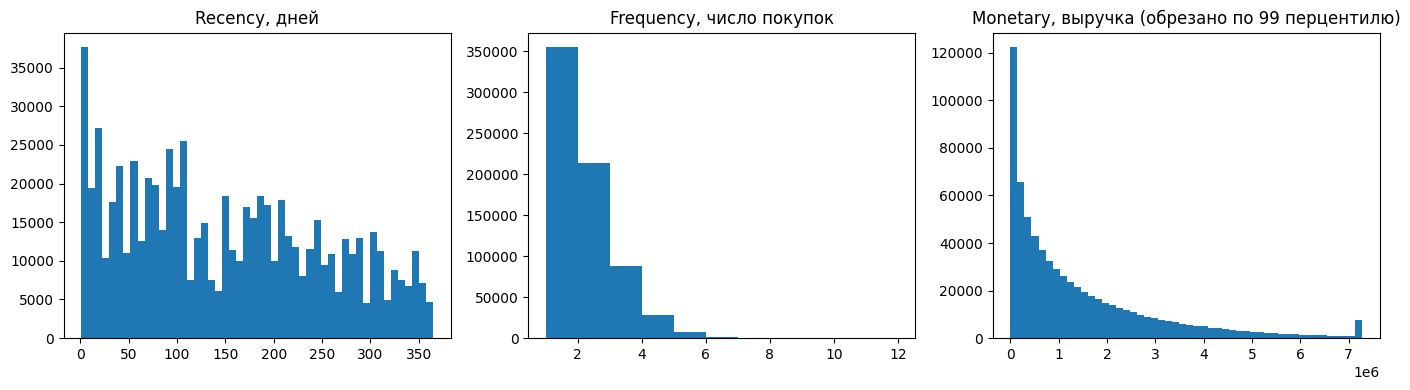

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(rfm["recency"], bins=50)
axes[0].set_title("Recency, дней")
axes[1].hist(rfm["frequency"], bins=range(1, 13))
axes[1].set_title("Frequency, число покупок")
axes[2].hist(rfm["monetary"].clip(upper=rfm["monetary"].quantile(0.99)), bins=50)
axes[2].set_title("Monetary, выручка (обрезано по 99 перцентилю)")
plt.tight_layout()
plt.show()

In [5]:
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)


def segment(row):
    r, f, m = row["r_score"], row["f_score"], row["m_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Лидеры"
    if f >= 4 and m >= 4:
        return "Лояльные"
    if r >= 4 and f <= 2:
        return "Новые"
    if r <= 2 and (f >= 3 or m >= 3):
        return "Под риском"
    if r <= 2 and f <= 2 and m <= 2:
        return "Спящие"
    return "Средние"


rfm["segment"] = rfm.apply(segment, axis=1)
rfm["segment"].value_counts()

segment
Средние       207568
Под риском    152536
Лидеры         94497
Спящие         88552
Новые          77710
Лояльные       72911
Name: count, dtype: int64

In [6]:
segment_summary = rfm.groupby("segment").agg(
    customers=("client_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_monetary=("monetary", "sum"),
)
segment_summary["revenue_share"] = segment_summary["total_monetary"] / segment_summary["total_monetary"].sum()
segment_summary.sort_values("total_monetary", ascending=False).round(1)

,customers,avg_recency,avg_frequency,avg_monetary,total_monetary,revenue_share
segment,,,,,,
Лидеры,94497,46.0,3.0,3252401.4,3.073422e+11,0.3
Лояльные,72911,183.8,2.6,3116840.7,2.272520e+11,0.2
Под риском,152536,259.1,1.3,1238575.4,1.889273e+11,0.2
Средние,207568,93.5,1.8,906904.5,1.882443e+11,0.2
Новые,77710,51.3,1.0,821013.4,6.380095e+10,0.1
Спящие,88552,267.7,1.0,185925.5,1.646407e+10,0.0


В отличие от ABC/XYZ сегментация реально разделяет клиентов по ценности. Лидеры и Лояльные вместе — 24.1% клиентов но 53.4% выручки. У обоих сегментов частота покупок заметно выше среднего (3.0 и 2.6 против 1.74 в целом по базе) — именно частота показывает такой результат, а не разовый крупный чек.

По сегментам:
- **Лидеры и Лояльные** — держат больше половины выручки разница у них в recency (46 дней против 184) 
Лояльные давно не покупали, но исторически ценны так же, как Чемпионы. Приоритет — не потерять, это самая дорогая часть базы.

- **Под риском** — второй по размеру сегмент (152 536 клиентов и  18.9% выручки) recency 259 дней при исторической частоте выше средней. Раньше покупали регулярно- сейчас нет, кандидаты на возвращение в первую очередь.

- **Новые** — recency низкий frequency пока 1 по построению сегмента. Ценность в том, доведутся ли до второй покупки: у Средних (frequency 1.8) monetary уже вдвое выше чем у Новых.
- **Спящие** — самый низкий monetary (185 925, в 17.5 раз меньше Лидеров) и самый долгий recency. Наименьший приоритет для затрат на реактивацию.

## Когорты

Когорта — месяц первой покупки клиента **в 2023 году** (не первой покупки за всю историю). Ретеншн — доля клиентов когорты купишвих хотя бы раз в каждый следующий месяц 2023 года.

In [7]:
txn = pd.read_sql(
    f"""
    select client_id, date_trunc('month', source_date) as month
    from staging.stg_sales
    where source_date >= '{YEAR_START}' and source_date < '{YEAR_END}'
    group by client_id, date_trunc('month', source_date)
    """,
    engine,
)

cohort_month = txn.groupby("client_id")["month"].min().rename("cohort_month")
txn = txn.join(cohort_month, on="client_id")
txn["period_number"] = (
    (txn["month"].dt.year - txn["cohort_month"].dt.year) * 12
    + (txn["month"].dt.month - txn["cohort_month"].dt.month)
)

cohort_sizes = txn[txn["period_number"] == 0].groupby("cohort_month")["client_id"].nunique()
retention = (
    txn.groupby(["cohort_month", "period_number"])["client_id"].nunique().unstack(fill_value=0)
)
retention_pct = retention.divide(cohort_sizes, axis=0)

# периоды за пределами 2023 года для конкретной когорты — не 0% ретеншна, а ещё не наступили, помечаю NaN
for i, cohort in enumerate(retention_pct.index):
    max_period = 11 - cohort.month + 1
    retention_pct.iloc[i, max_period + 1 :] = float("nan")

retention_pct.round(3)

period_number,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2023-01-01 00:00:00+00:00,1.0,0.084,0.113,0.085,0.099,0.117,0.088,0.076,0.095,0.096,0.076,0.102
2023-02-01 00:00:00+00:00,1.0,0.113,0.085,0.098,0.117,0.088,0.075,0.093,0.097,0.079,0.101,NaN
2023-03-01 00:00:00+00:00,1.0,0.084,0.097,0.118,0.090,0.074,0.094,0.097,0.079,0.103,NaN,NaN
2023-04-01 00:00:00+00:00,1.0,0.100,0.116,0.091,0.076,0.095,0.096,0.079,0.100,NaN,NaN,NaN
2023-05-01 00:00:00+00:00,1.0,0.117,0.089,0.078,0.096,0.096,0.077,0.103,NaN,NaN,NaN,NaN
2023-06-01 00:00:00+00:00,1.0,0.089,0.073,0.094,0.095,0.077,0.101,NaN,NaN,NaN,NaN,NaN
2023-07-01 00:00:00+00:00,1.0,0.077,0.093,0.096,0.078,0.100,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-01 00:00:00+00:00,1.0,0.098,0.096,0.076,0.102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01 00:00:00+00:00,1.0,0.093,0.080,0.102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


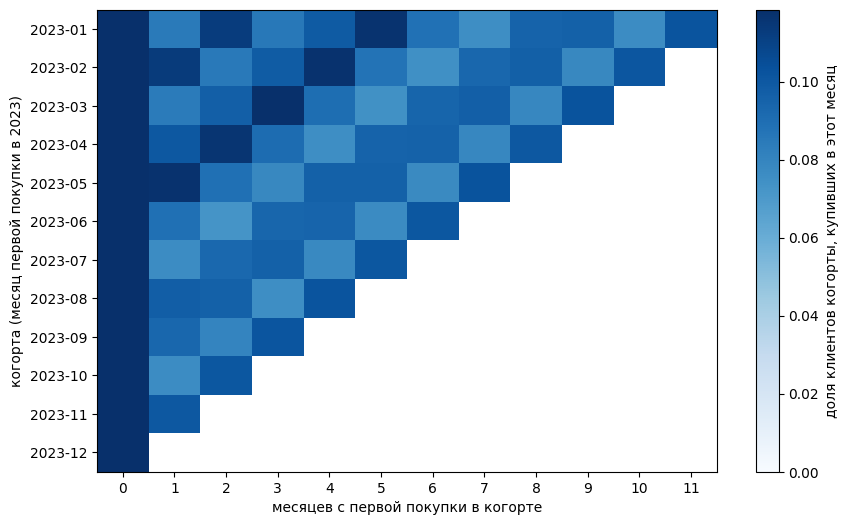

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(retention_pct, aspect="auto", cmap="Blues", vmin=0, vmax=retention_pct.iloc[:, 1:].max().max())
ax.set_yticks(range(len(retention_pct.index)))
ax.set_yticklabels([d.strftime("%Y-%m") for d in retention_pct.index])
ax.set_xticks(range(retention_pct.shape[1]))
ax.set_xlabel("месяцев с первой покупки в когорте")
ax.set_ylabel("когорта (месяц первой покупки в 2023)")
fig.colorbar(im, label="доля клиентов когорты, купивших в этот месяц")
plt.show()

In [9]:
avg_by_period = retention_pct.drop(columns=0).mean()
print("средний ретеншн по периодам (без периода 0):")
print(avg_by_period.round(3))
print()
print("разброс средних по всем периодам 1-11:", round(avg_by_period.max() - avg_by_period.min(), 3))

средний ретеншн по периодам (без периода 0):
period_number
1     0.094
2     0.094
3     0.093
4     0.094
5     0.092
6     0.088
7     0.089
8     0.093
9     0.092
10    0.089
11    0.102
dtype: float64

разброс средних по всем периодам 1-11: 0.014


Ретеншн держится в узком коридоре 8.8-10.2% на каждый последующий месяцразброс между периодом 1 и периодом 11 - всего 1.4 п.п., затухания нет вообще. 
Обычно кривая ретеншна падает здесь этого нет — вероятность повторной покупки в любой месяц одинаковая что для клиента первого месяца, что для клиента одиннадцатого.

Практический вывод: в этих данных нет смысла искать критичное окно удержания в начале жизни клиента, для которого стоило бы строить отдельную программу. Вероятность повторной покупки — величина примерно постоянная.

## Итог

В отличие от ассортимента, здесь база  неоднородна: 24.1% клиентов (Лидеры + Лояльные) дают 53.4% выручк и разница держится на частоте покупок. Это единственная метрика в двух исследованиях каторую содержательно есть смысл растить: перевод клиента из 1 покупки в 2-3 поднимает monetary в разы (821 013 у Новых с frequency 1 против 3 252 401 у Лидеров с frequency 3 а не на проценты.

Дальше по метрикам:

- **Частота (F) — то что стоит растить.** Она напрямую связана с выручкой на клиента и единственная из RFM-метрик поддаётся управлению Программа повторных покупок (email/push после первой покупки персональные рекомендации) не противоречит уже установленным фактам и остаётся кандидатом.
- **Recency сама по себе — не цель.** Ретеншн не падает со стажем значит нет "критичного окна" в первые недели которое нужно закрывать любой ценой. Приоритет по recency стоит расставлять не по времени с последней покупки а по тому сколько клиент стоил раньше (Под риском -  не Спящие).
- **Скидками возвращать не получится.** И для ассортимента и здесь нет оснований верить, что промо на скидку сдвинет поведение — единственный проверенный на данных рычаг оказался нерабочим, дальше нужны либо другие рычаги (персонализация и  ассортиментные рекомендации), либо новые данные чтобы проверить рычаги, которых в этих данных нет.

Ограничение те же: нет данных о канале привлечения, стоимости привлечения, реальной себестоимости. Можно расставить приоритеты между сегментами по выручке, но нельзя посчитать окупаемость конкретных действий — во сколько обойдётся возвращение "Под риском" и вернёт ли он больше, чем потратится без учёта затрат сказать нельзя.